# Basketball Detection - Model Evaluation

Evaluate the current best YOLO26n model produced during training.

This notebook loads the latest `best.pt` checkpoint and evaluates its performance on the basketball dataset.

Classes:
- `basketball`
- `hoop`
- `player`

## Notebook Structure

1. Environment Setup
2. Load Best Model
3. Validation Metrics
4. Per-Class Evaluation
5. Prediction Examples
6. Error Analysis

## 1. Environment Setup

Import the required libraries and verify that the GPU is available for model evaluation.

In [41]:
from pathlib import Path
import torch
from ultralytics import YOLO


project_root = Path.cwd()

best_model_path = (
    project_root
    / "results"
    / "yolo26n"
    / "baseline"
    / "weights"
    / "best.pt"
)

print("CUDA available:", torch.cuda.is_available())
print("Best model exists:", best_model_path.exists())
print("Model path:", best_model_path)

CUDA available: True
Best model exists: True
Model path: C:\Users\shaha\jupyter_notebooks\basketball_score_tracking\results\yolo26n\baseline\weights\best.pt


## 2. Load Best Model

Load the current best YOLO26n checkpoint produced during training.

In [42]:
from pathlib import Path
from ultralytics import YOLO

best_model_path = (
    Path.cwd()
    / "results"
    / "yolo26n"
    / "baseline"
    / "weights"
    / "best.pt"
)

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Best model not found: {best_model_path}"
    )

model = YOLO(str(best_model_path))

print("Current best model loaded successfully.")
print("Model path:", best_model_path)
print("Task:", model.task)
print("Classes:", model.names)

Current best model loaded successfully.
Model path: C:\Users\shaha\jupyter_notebooks\basketball_score_tracking\results\yolo26n\baseline\weights\best.pt
Task: detect
Classes: {0: 'basketball', 1: 'hoop', 2: 'player'}


## 3. Validation Metrics

Evaluate the best model on the validation dataset and report the main detection metrics, including precision, recall, mAP50, and mAP50-95.

In [43]:
from pathlib import Path

data_yaml_path = (
    Path.cwd()
    / "data"
    / "processed"
    / "basketball_dataset_final"
    / "data.yaml"
)

validation_metrics = model.val(
    data=str(data_yaml_path),
    split="val",
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    plots=True
)

print("\nValidation Metrics")
print(f"Precision:  {validation_metrics.box.mp:.4f}")
print(f"Recall:     {validation_metrics.box.mr:.4f}")
print(f"mAP50:      {validation_metrics.box.map50:.4f}")
print(f"mAP50-95:   {validation_metrics.box.map:.4f}")

Ultralytics 8.4.138  Python-3.12.14 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
WARNING val: Slow image access detected (ping: 0.20.0 ms, read: 49.725.2 MB/s, size: 67.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\shaha\jupyter_notebooks\basketball_score_tracking\data\processed\basketball_dataset_final\validation\labels.cache... 7171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7171/7171  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 449/449 4.0it/s 1:520.2sss
                   all       7171      27795       0.86      0.778      0.856      0.564
            basketball       6092       7125      0.843      0.714      0.801      0.526
                  hoop       4858       5002     

## 4. Per-Class Evaluation

Analyze model performance separately for each class:

- `basketball`
- `hoop`
- `player`

Compare precision, recall, and mAP values to identify which classes are detected well and which require further improvement.

In [44]:
class_names = model.names

precision = validation_metrics.box.p
recall = validation_metrics.box.r
map50 = validation_metrics.box.ap50
map50_95 = validation_metrics.box.ap

print("Per-Class Evaluation\n")

for class_id, class_name in class_names.items():
    print(f"{class_name}")
    print(f"  Precision:  {precision[class_id]:.4f}")
    print(f"  Recall:     {recall[class_id]:.4f}")
    print(f"  mAP50:      {map50[class_id]:.4f}")
    print(f"  mAP50-95:   {map50_95[class_id]:.4f}")
    print()

Per-Class Evaluation

basketball
  Precision:  0.8429
  Recall:     0.7140
  mAP50:      0.8014
  mAP50-95:   0.5263

hoop
  Precision:  0.8848
  Recall:     0.8824
  mAP50:      0.9326
  mAP50-95:   0.6528

player
  Precision:  0.8519
  Recall:     0.7369
  mAP50:      0.8352
  mAP50-95:   0.5115



## 5. Prediction Examples

Visualize model predictions on selected validation images to inspect bounding boxes, confidence scores, missed detections, and false positives.

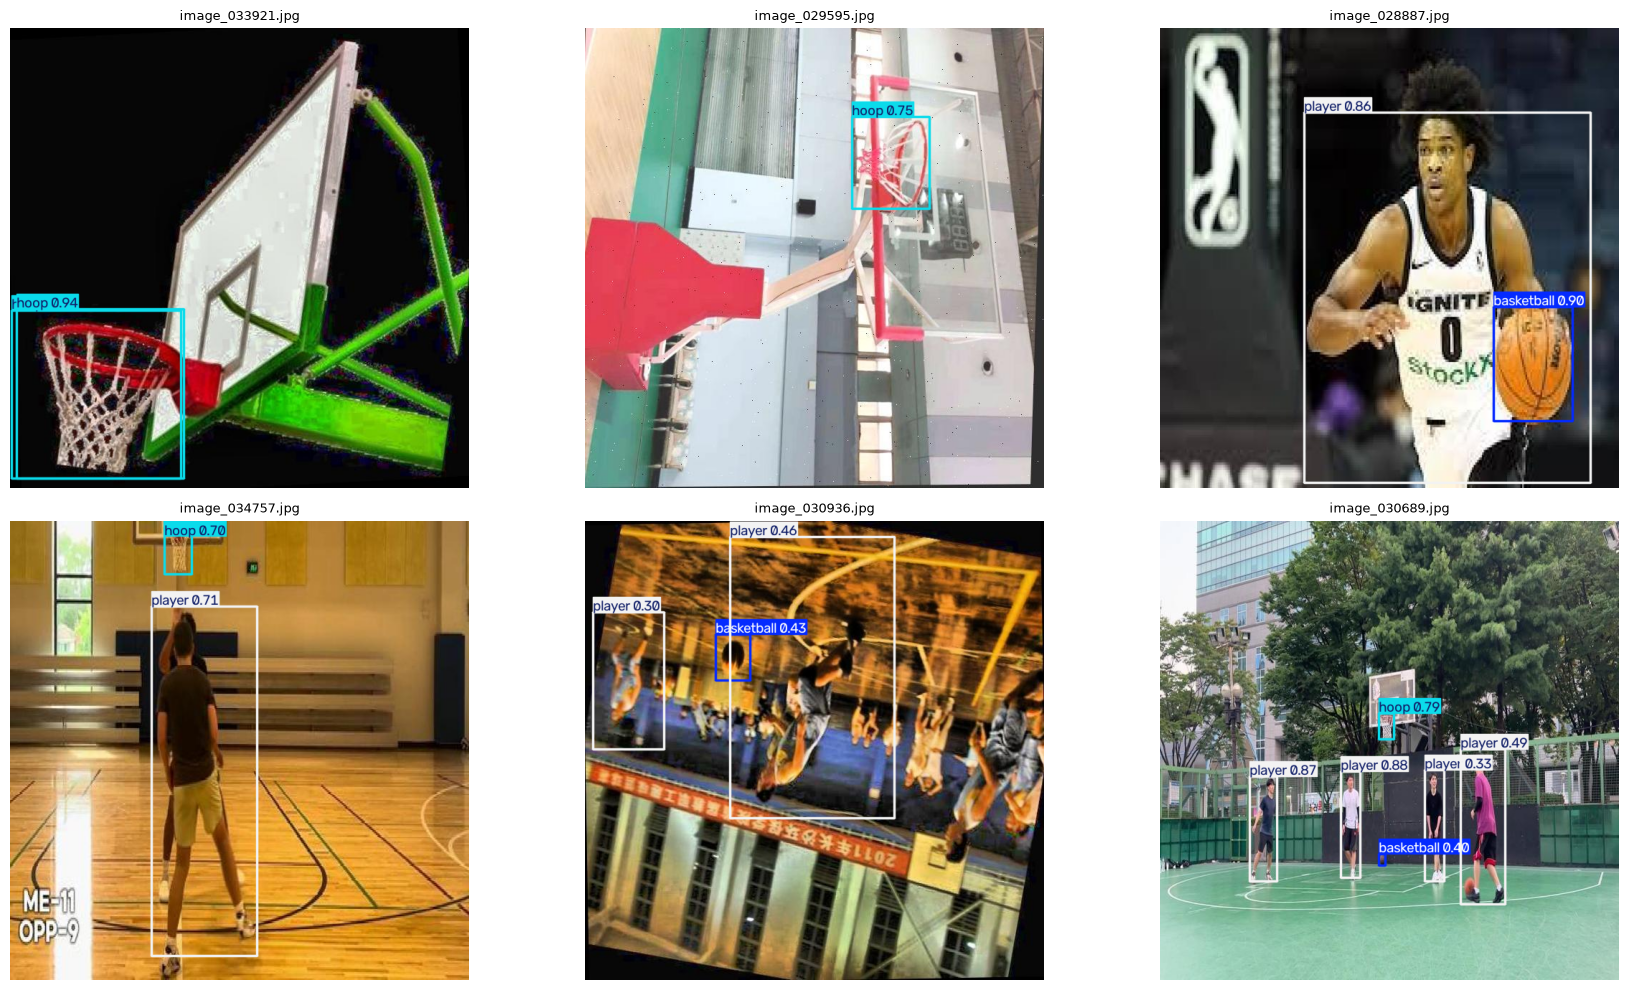

In [45]:
import random
import matplotlib.pyplot as plt


validation_images = (
    Path.cwd()
    / "data"
    / "processed"
    / "basketball_dataset_final"
    / "validation"
    / "images"
)

image_paths = [
    path
    for path in validation_images.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

random.seed(42)
selected_images = random.sample(image_paths, 6)

prediction_results = model.predict(
    source=[str(path) for path in selected_images],
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis, result, image_path in zip(
    axes,
    prediction_results,
    selected_images
):
    annotated_image = result.plot()

    # Convert BGR to RGB for Matplotlib
    annotated_image = annotated_image[:, :, ::-1]

    axis.imshow(annotated_image)
    axis.set_title(image_path.name, fontsize=9)
    axis.axis("off")

plt.tight_layout()
plt.show()

## 6. Performance and Error Analysis

This section evaluates how the model develops throughout training and analyzes its main detection errors on the validation set.

The analysis is divided into four parts:

- **6.1 Training Progress** - Monitor the overall training progress across epochs.
- **6.2 Per-Class Progress** - Track performance changes for `basketball`, `hoop`, and `player`.
- **6.3 Detection Error Analysis** - Analyze common detection failures across all classes.
- **6.4 Basketball-Specific Analysis** - Perform additional analysis of basketball detection because of its importance for tracking and shot detection.

### 6.1 Training Progress

Monitor the overall training progress across epochs using the training history stored in `results.csv`.

This analysis focuses on:
- Training and validation loss trends
- Overall validation Precision and Recall
- Overall validation mAP50 and mAP50-95

These trends help determine whether the model is improving, reaching a plateau, or showing signs of overfitting.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt


results_csv = (
    Path.cwd()
    / "results"
    / "yolo26n"
    / "baseline"
    / "results.csv"
)

if not results_csv.exists():
    raise FileNotFoundError(
        f"Training results not found: {results_csv}"
    )

history = pd.read_csv(results_csv)

# Remove extra spaces from column names
history.columns = history.columns.str.strip()

print("Completed epochs:", len(history))

display(history.tail())

Completed epochs: 4


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,2911.52,1.37607,2.43377,0.01225,0.82132,0.73362,0.81270,0.50517,1.28453,1.20115,0.01471,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,5992.39,1.36181,1.25057,0.01243,0.84342,0.76509,0.84124,0.55129,1.25993,0.91764,0.01540,0.019797,0.006599,0.019797,0.006599,0.019797,0.006599,0.019797,0.006599
2,3,8487.38,1.42872,1.23011,0.01333,0.83053,0.75391,0.83296,0.53233,1.32177,0.95699,0.01691,0.029400,0.009800,0.029400,0.009800,0.029400,0.009800,0.029400,0.009800
3,4,2400.27,1.45987,1.22840,0.01375,0.85941,0.77825,0.85636,0.56378,1.27992,0.84787,0.01581,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703


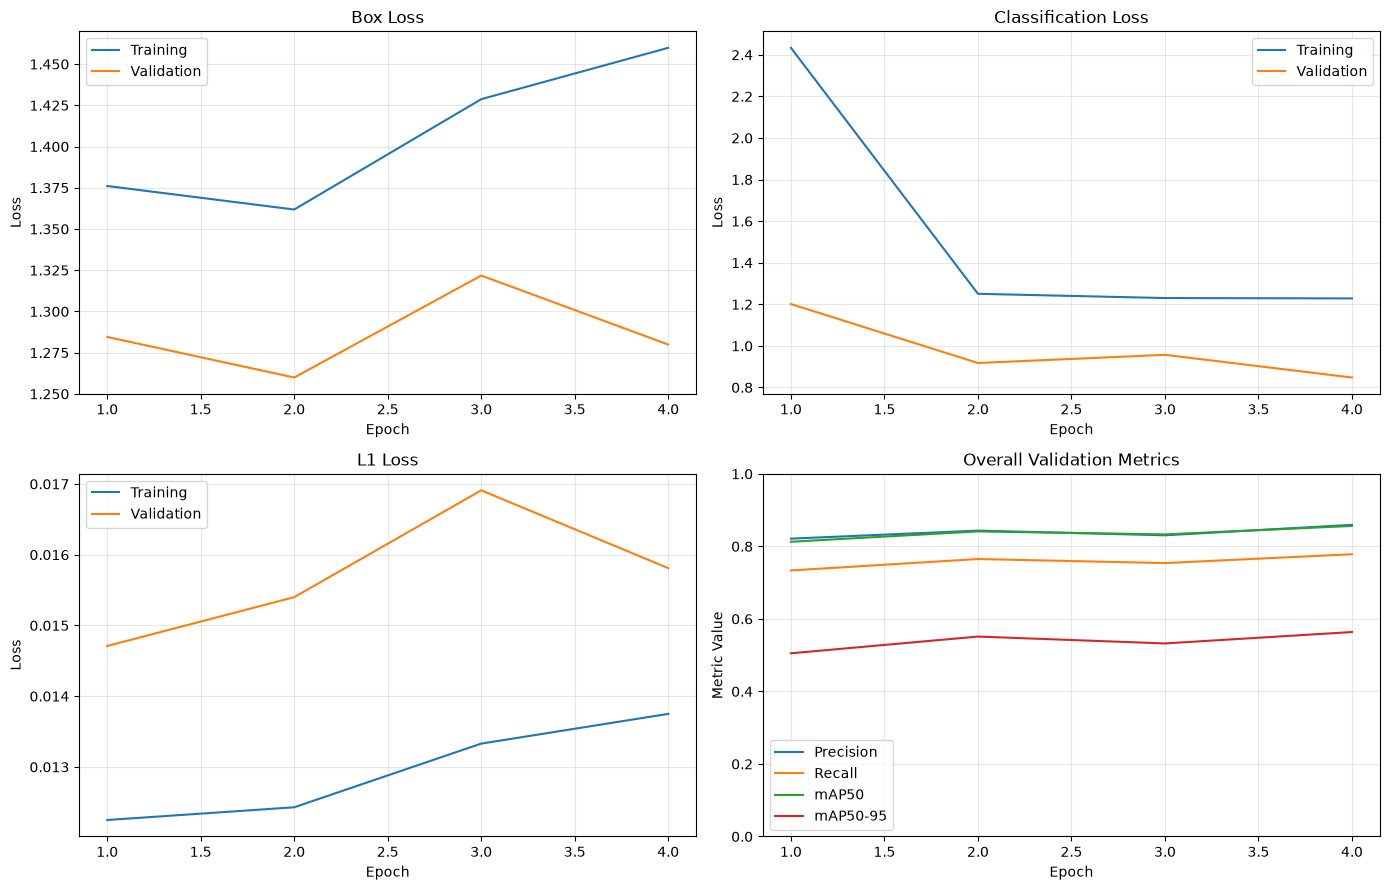

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Box Loss
axes[0, 0].plot(
    history["epoch"],
    history["train/box_loss"],
    label="Training"
)
axes[0, 0].plot(
    history["epoch"],
    history["val/box_loss"],
    label="Validation"
)
axes[0, 0].set_title("Box Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# Classification Loss
axes[0, 1].plot(
    history["epoch"],
    history["train/cls_loss"],
    label="Training"
)
axes[0, 1].plot(
    history["epoch"],
    history["val/cls_loss"],
    label="Validation"
)
axes[0, 1].set_title("Classification Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)


# L1 Loss
axes[1, 0].plot(
    history["epoch"],
    history["train/l1_loss"],
    label="Training"
)
axes[1, 0].plot(
    history["epoch"],
    history["val/l1_loss"],
    label="Validation"
)
axes[1, 0].set_title("L1 Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# Overall Validation Metrics
axes[1, 1].plot(
    history["epoch"],
    history["metrics/precision(B)"],
    label="Precision"
)
axes[1, 1].plot(
    history["epoch"],
    history["metrics/recall(B)"],
    label="Recall"
)
axes[1, 1].plot(
    history["epoch"],
    history["metrics/mAP50(B)"],
    label="mAP50"
)
axes[1, 1].plot(
    history["epoch"],
    history["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

axes[1, 1].set_title("Overall Validation Metrics")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Metric Value")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

#### Graph Interpretation

- **Box Loss - Training vs Validation**  
  Measures bounding-box localization quality. Lower values are better.
  
  What to look for:
  - Training ↓ and Validation ↓ => localization is improving.
  - Training ↓ while Validation ↑ => possible overfitting.
  - Both stop improving => the model may be reaching a plateau.

- **Classification Loss - Training vs Validation**  
  Measures how well the model distinguishes between `basketball`, `hoop`, and `player`. Lower values are better.
  
  What to look for:
  - Training ↓ and Validation ↓ => class prediction is improving.
  - Training ↓ while Validation ↑ => possible overfitting.
  - Both remain stable => classification improvement may be reaching a plateau.

- **L1 Loss - Training vs Validation**  
  Measures bounding-box coordinate prediction error. Lower values are better.
  
  What to look for:
  - Training ↓ and Validation ↓ => bounding-box coordinates are becoming more accurate.
  - Training ↓ while Validation ↑ => possible overfitting.
  - Stable values → localization improvement may be slowing down.

- **Overall Validation Metrics**  
  Shows Precision, Recall, mAP50, and mAP50-95 across epochs. Higher values are better.
  
  What to look for:
  - Metrics ↑ => detection performance is improving.
  - Metrics remain stable => the model may be reaching a performance plateau.
  - Metrics ↓ across several epochs => validation performance may be getting worse.

The loss and validation metric trends should be interpreted together. A single epoch can fluctuate, so the overall trend across multiple epochs is more important than one isolated increase or decrease.

### 6.2 Per-Class Progress

Track how the current best model performs for each class as training progresses.

The evaluation history is saved after each evaluation run, allowing performance to be compared across different stages of training.

The analysis focuses on:
- Recall for `basketball`, `hoop`, and `player`
- mAP50-95 for `basketball`, `hoop`, and `player`

Recall helps measure how many objects of each class are successfully detected, while mAP50-95 provides a stricter measure of overall detection and localization quality.

In [48]:
evaluation_history_path = (
    Path.cwd()
    / "results"
    / "evaluation_history.csv"
)

completed_epochs = int(history["epoch"].max())

class_ids = list(model.names.keys())

current_evaluation = pd.DataFrame({
    "completed_epochs": [completed_epochs] * len(class_ids),
    "class": [model.names[class_id] for class_id in class_ids],
    "precision": validation_metrics.box.p,
    "recall": validation_metrics.box.r,
    "mAP50": validation_metrics.box.ap50,
    "mAP50-95": validation_metrics.box.ap
})


if evaluation_history_path.exists():
    evaluation_history = pd.read_csv(evaluation_history_path)

    # Replace an existing evaluation from the same training stage
    evaluation_history = evaluation_history[
        evaluation_history["completed_epochs"] != completed_epochs
    ]

    evaluation_history = pd.concat(
        [evaluation_history, current_evaluation],
        ignore_index=True
    )

else:
    evaluation_history = current_evaluation


evaluation_history = evaluation_history.sort_values(
    ["completed_epochs", "class"]
)

evaluation_history.to_csv(
    evaluation_history_path,
    index=False
)

print(f"Evaluation saved after {completed_epochs} completed epochs.")

display(evaluation_history)

Evaluation saved after 4 completed epochs.


,completed_epochs,class,precision,recall,mAP50,mAP50-95
0,3,basketball,0.842534,0.709614,0.796574,0.520283
1,3,hoop,0.868152,0.838265,0.905968,0.637757
2,3,player,0.826484,0.744575,0.821405,0.495483
3,4,basketball,0.842917,0.713968,0.801368,0.526256
4,4,hoop,0.884772,0.882447,0.932581,0.652787
5,4,player,0.851911,0.736894,0.835218,0.511547


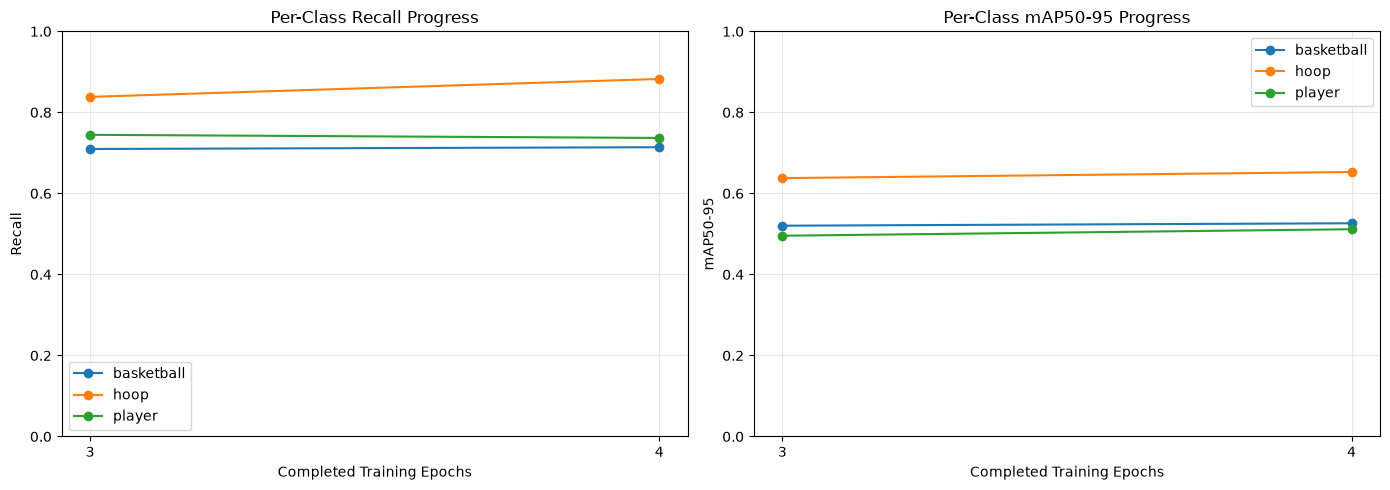

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = ["basketball", "hoop", "player"]


# Recall Progress
for class_name in class_names:
    class_history = evaluation_history[
        evaluation_history["class"] == class_name
    ]

    axes[0].plot(
        class_history["completed_epochs"],
        class_history["recall"],
        marker="o",
        label=class_name
    )

axes[0].set_title("Per-Class Recall Progress")
axes[0].set_xlabel("Completed Training Epochs")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)


# mAP50-95 Progress
for class_name in class_names:
    class_history = evaluation_history[
        evaluation_history["class"] == class_name
    ]

    axes[1].plot(
        class_history["completed_epochs"],
        class_history["mAP50-95"],
        marker="o",
        label=class_name
    )

axes[1].set_title("Per-Class mAP50-95 Progress")
axes[1].set_xlabel("Completed Training Epochs")
axes[1].set_ylabel("mAP50-95")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)




completed_epoch_values = sorted(
    evaluation_history["completed_epochs"].unique()
)

axes[0].set_xticks(completed_epoch_values)
axes[1].set_xticks(completed_epoch_values)

if len(completed_epoch_values) == 1:
    epoch = completed_epoch_values[0]

    axes[0].set_xlim(epoch - 0.5, epoch + 0.5)
    axes[1].set_xlim(epoch - 0.5, epoch + 0.5)


plt.tight_layout()
plt.show()

#### Graph Interpretation

- **Per-Class Recall Progress**  
  Shows how the ability to detect objects from each class changes as training continues.
  
  What to look for:
  - Recall ↑ => fewer objects from that class are being missed.
  - Recall remains stable => detection performance for that class may be reaching a plateau.
  - Recall ↓ across several evaluations → the model may be getting worse at detecting that class.

- **Per-Class mAP50-95 Progress**  
  Shows how the overall detection and bounding-box localization quality changes for each class over time.
  
  What to look for:
  - mAP50-95 ↑ => detection quality and localization are improving.
  - mAP50-95 remains stable => performance may be reaching a plateau.
  - mAP50-95 ↓ across several evaluations => performance for that class may be degrading.

The trends should be compared across all three classes to make sure that improvement in the overall model is not caused by one strong class hiding weaker performance in another class.

Particular attention should be given to `basketball` Recall because missed basketball detections can directly affect the later tracking and shot-detection stages.

### 6.3 Detection Error Analysis

Analyze the main detection errors produced by the current best model on the validation set.

This section is divided into three parts:

- **6.3.1 TP / FP / FN Summary** - Measure the number of correct detections, false positives, and missed detections for each class.
- **6.3.2 Confusion Matrix** - Identify how predictions are distributed between `basketball`, `hoop`, `player`, and background.
- **6.3.3 Error Examples** - Inspect real validation images containing missed detections, false positives, and localization errors.

Together, these analyses provide both a quantitative summary of the model's errors and a visual understanding of the situations in which those errors occur.

#### 6.3.1 Confidence Threshold Analysis

Evaluate different confidence thresholds on the validation set while keeping the IoU matching threshold fixed at 0.50.

For each class, the analysis measures:
- Precision
- Recall
- F1-score

The goal is to select an appropriate operating confidence threshold for each class instead of using the same default threshold for all detections.

Lower confidence thresholds generally increase Recall but may also increase False Positives. Higher thresholds generally improve Precision but may increase missed detections.

The initial threshold for each class is selected using the highest F1-score. Basketball detection can later be adjusted separately if higher Recall is required for tracking and shot detection.

In [50]:
import numpy as np
import pandas as pd
from pathlib import Path


validation_images = (
    Path.cwd()
    / "data"
    / "processed"
    / "basketball_dataset_final"
    / "validation"
    / "images"
)

validation_labels = (
    Path.cwd()
    / "data"
    / "processed"
    / "basketball_dataset_final"
    / "validation"
    / "labels"
)

IOU_THRESHOLD = 0.50

confidence_thresholds = np.arange(
    0.05,
    0.96,
    0.05
)


def yolo_to_xyxy(label, image_width, image_height):
    class_id, x_center, y_center, width, height = label

    x_center *= image_width
    y_center *= image_height
    width *= image_width
    height *= image_height

    return np.array([
        x_center - width / 2,
        y_center - height / 2,
        x_center + width / 2,
        y_center + height / 2
    ])


def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (
        max(0, box1[2] - box1[0])
        * max(0, box1[3] - box1[1])
    )

    area2 = (
        max(0, box2[2] - box2[0])
        * max(0, box2[3] - box2[1])
    )

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


prediction_records = {
    class_id: []
    for class_id in model.names
}

ground_truth_counts = {
    class_id: 0
    for class_id in model.names
}


# Use a very low confidence threshold so that the same predictions
# can be evaluated at multiple confidence thresholds later.
prediction_stream = model.predict(
    source=str(validation_images),
    imgsz=640,
    conf=0.01,
    device=0,
    stream=True,
    verbose=False
)


for result in prediction_stream:
    image_path = Path(result.path)
    label_path = validation_labels / f"{image_path.stem}.txt"

    image_height, image_width = result.orig_shape

    ground_truth = {
        class_id: []
        for class_id in model.names
    }

    if label_path.exists():
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines():

            values = list(map(float, line.split()))
            class_id = int(values[0])

            ground_truth[class_id].append(
                yolo_to_xyxy(
                    values,
                    image_width,
                    image_height
                )
            )

            ground_truth_counts[class_id] += 1

    predictions = {
        class_id: []
        for class_id in model.names
    }

    for box in result.boxes:
        class_id = int(box.cls.item())

        predictions[class_id].append({
            "confidence": float(box.conf.item()),
            "box": box.xyxy[0].cpu().numpy()
        })

    for class_id in model.names:
        gt_boxes = ground_truth[class_id]

        pred_boxes = sorted(
            predictions[class_id],
            key=lambda item: item["confidence"],
            reverse=True
        )

        matched_gt = set()

        for prediction in pred_boxes:
            best_iou = 0
            best_gt_index = None

            for gt_index, gt_box in enumerate(gt_boxes):
                if gt_index in matched_gt:
                    continue

                iou = calculate_iou(
                    prediction["box"],
                    gt_box
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = gt_index

            is_true_positive = (
                best_gt_index is not None
                and best_iou >= IOU_THRESHOLD
            )

            if is_true_positive:
                matched_gt.add(best_gt_index)

            prediction_records[class_id].append({
                "confidence": prediction["confidence"],
                "is_tp": is_true_positive
            })


threshold_results = []

for class_id, class_name in model.names.items():
    records = prediction_records[class_id]
    total_gt = ground_truth_counts[class_id]

    for threshold in confidence_thresholds:
        active_predictions = [
            record
            for record in records
            if record["confidence"] >= threshold
        ]

        tp = sum(
            record["is_tp"]
            for record in active_predictions
        )

        fp = len(active_predictions) - tp
        fn = total_gt - tp

        precision = (
            tp / (tp + fp)
            if tp + fp > 0
            else 0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn > 0
            else 0
        )

        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall > 0
            else 0
        )

        threshold_results.append({
            "Class": class_name,
            "Confidence": round(float(threshold), 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })


threshold_results = pd.DataFrame(threshold_results)

best_threshold_rows = (
    threshold_results.loc[
        threshold_results.groupby("Class")["F1"].idxmax()
    ]
    .sort_values("Class")
    .reset_index(drop=True)
)

selected_thresholds = {
    class_id: float(
        best_threshold_rows.loc[
            best_threshold_rows["Class"] == class_name,
            "Confidence"
        ].iloc[0]
    )
    for class_id, class_name in model.names.items()
}

display(best_threshold_rows.round(4))

,Class,Confidence,Precision,Recall,F1
0,basketball,0.25,0.8307,0.7137,0.7678
1,hoop,0.30,0.8994,0.8671,0.8829
2,player,0.25,0.8446,0.7419,0.7899


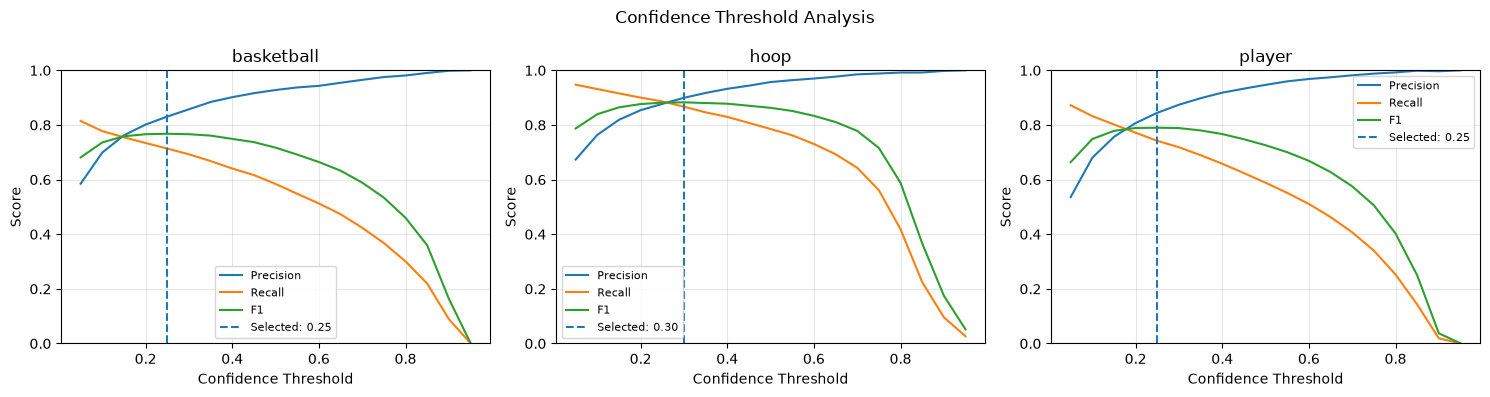

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, class_name in zip(
    axes,
    model.names.values()
):
    class_results = threshold_results[
        threshold_results["Class"] == class_name
    ]

    ax.plot(
        class_results["Confidence"],
        class_results["Precision"],
        label="Precision"
    )

    ax.plot(
        class_results["Confidence"],
        class_results["Recall"],
        label="Recall"
    )

    ax.plot(
        class_results["Confidence"],
        class_results["F1"],
        label="F1"
    )

    best_row = best_threshold_rows[
        best_threshold_rows["Class"] == class_name
    ].iloc[0]

    ax.axvline(
        best_row["Confidence"],
        linestyle="--",
        label=f"Selected: {best_row['Confidence']:.2f}"
    )

    ax.set_title(class_name)
    ax.set_xlabel("Confidence Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Confidence Threshold Analysis")
plt.tight_layout()
plt.show()

#### 6.3.2 Confusion Matrix

Evaluate the current best model using the class-specific confidence thresholds selected in Section 6.3.1.

The confusion matrix shows:
- Correct detections for each class
- Confusion between `basketball`, `hoop`, and `player`
- Ground-truth objects missed as background
- False detections produced from the background

The IoU matching threshold remains fixed at 0.50, while each class uses its selected confidence threshold.

Higher values along the main diagonal represent correct detections, while off-diagonal values represent classification errors, missed detections, or false positives.

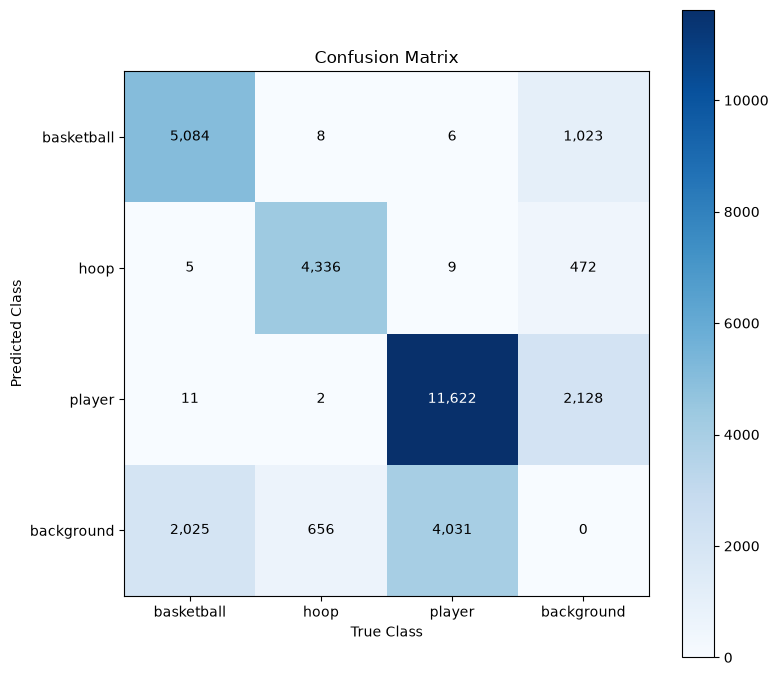

In [52]:
num_classes = len(model.names)
BACKGROUND_ID = num_classes

# Extra row and column are used for background
confusion_matrix = np.zeros(
    (num_classes + 1, num_classes + 1),
    dtype=int
)


prediction_stream = model.predict(
    source=str(validation_images),
    imgsz=640,
    conf=0.01,
    device=0,
    stream=True,
    verbose=False
)


for result in prediction_stream:
    image_path = Path(result.path)
    label_path = validation_labels / f"{image_path.stem}.txt"

    image_height, image_width = result.orig_shape

    ground_truth = []

    if label_path.exists():
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines():

            values = list(map(float, line.split()))
            class_id = int(values[0])

            ground_truth.append({
                "class_id": class_id,
                "box": yolo_to_xyxy(
                    values,
                    image_width,
                    image_height
                )
            })

    predictions = []

    for box in result.boxes:
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        # Apply the selected confidence threshold for each class
        if confidence >= selected_thresholds[class_id]:
            predictions.append({
                "class_id": class_id,
                "confidence": confidence,
                "box": box.xyxy[0].cpu().numpy()
            })

    predictions = sorted(
        predictions,
        key=lambda item: item["confidence"],
        reverse=True
    )

    matched_gt = set()

    for prediction in predictions:
        best_iou = 0
        best_gt_index = None

        for gt_index, gt in enumerate(ground_truth):
            if gt_index in matched_gt:
                continue

            iou = calculate_iou(
                prediction["box"],
                gt["box"]
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_index = gt_index

        predicted_class = prediction["class_id"]

        if (
            best_gt_index is not None
            and best_iou >= IOU_THRESHOLD
        ):
            true_class = ground_truth[
                best_gt_index
            ]["class_id"]

            confusion_matrix[
                predicted_class,
                true_class
            ] += 1

            matched_gt.add(best_gt_index)

        else:
            # Prediction with no matching ground-truth object
            confusion_matrix[
                predicted_class,
                BACKGROUND_ID
            ] += 1

    # Ground-truth objects that were not detected
    for gt_index, gt in enumerate(ground_truth):
        if gt_index not in matched_gt:
            confusion_matrix[
                BACKGROUND_ID,
                gt["class_id"]
            ] += 1


# Visualize the confusion matrix
class_labels = [
    model.names[i]
    for i in range(num_classes)
] + ["background"]

fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(
    confusion_matrix,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))

ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)

ax.set_xlabel("True Class")
ax.set_ylabel("Predicted Class")
ax.set_title("Confusion Matrix")

threshold = confusion_matrix.max() / 2

for row in range(confusion_matrix.shape[0]):
    for col in range(confusion_matrix.shape[1]):
        value = confusion_matrix[row, col]

        ax.text(
            col,
            row,
            f"{int(value):,}",
            ha="center",
            va="center",
            color="white" if value > threshold else "black"
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

#### 6.3.3 Error Examples

Inspect real validation images containing detection errors produced by the current best model using the class-specific confidence thresholds selected in Section 6.3.1.

The examples focus on:
- Missed detections
- False positives
- Poorly localized bounding boxes
- Correct detections with confidence close to the selected threshold

The IoU matching threshold remains fixed at 0.50.

Visual inspection helps identify common situations that cause errors, such as small objects, occlusion, difficult viewing angles, motion blur, or crowded scenes.

In [53]:
error_types = [
    "Missed Detection",
    "False Positive",
    "Poor Localization",
    "Low Confidence"
]

error_examples = {
    class_name: {
        error_type: None
        for error_type in error_types
    }
    for class_name in model.names.values()
}

POOR_LOCALIZATION_MIN_IOU = 0.10
LOW_CONFIDENCE_MARGIN = 0.10


# Use a very low prediction threshold so class-specific
# thresholds can be applied manually.
prediction_stream = model.predict(
    source=str(validation_images),
    imgsz=640,
    conf=0.01,
    device=0,
    stream=True,
    verbose=False
)


for result in prediction_stream:
    image_path = Path(result.path)
    label_path = validation_labels / f"{image_path.stem}.txt"

    image_height, image_width = result.orig_shape

    ground_truth = {
        class_id: []
        for class_id in model.names
    }

    if label_path.exists():
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines():

            values = list(map(float, line.split()))
            class_id = int(values[0])

            ground_truth[class_id].append(
                yolo_to_xyxy(
                    values,
                    image_width,
                    image_height
                )
            )

    predictions = {
        class_id: []
        for class_id in model.names
    }

    for box in result.boxes:
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        # Apply the selected threshold for this class
        if confidence >= selected_thresholds[class_id]:
            predictions[class_id].append({
                "confidence": confidence,
                "box": box.xyxy[0].cpu().numpy()
            })

    for class_id, class_name in model.names.items():
        gt_boxes = ground_truth[class_id]

        pred_boxes = sorted(
            predictions[class_id],
            key=lambda item: item["confidence"],
            reverse=True
        )

        matched_gt = set()
        matched_predictions = set()
        correct_matches = []

        # Match predictions to ground-truth boxes
        for pred_index, prediction in enumerate(pred_boxes):
            best_iou = 0
            best_gt_index = None

            for gt_index, gt_box in enumerate(gt_boxes):
                if gt_index in matched_gt:
                    continue

                iou = calculate_iou(
                    prediction["box"],
                    gt_box
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = gt_index

            if (
                best_gt_index is not None
                and best_iou >= IOU_THRESHOLD
            ):
                matched_gt.add(best_gt_index)
                matched_predictions.add(pred_index)

                correct_matches.append({
                    "prediction": prediction,
                    "gt_box": gt_boxes[best_gt_index],
                    "iou": best_iou
                })

        # Missed Detection
        if error_examples[class_name]["Missed Detection"] is None:
            for gt_index, gt_box in enumerate(gt_boxes):
                if gt_index not in matched_gt:
                    error_examples[class_name]["Missed Detection"] = {
                        "image": image_path,
                        "gt_box": gt_box
                    }
                    break

        # Low Confidence
        if error_examples[class_name]["Low Confidence"] is None:
            selected_threshold = selected_thresholds[class_id]

            for match in correct_matches:
                confidence = match["prediction"]["confidence"]

                if (
                    confidence
                    <= selected_threshold + LOW_CONFIDENCE_MARGIN
                ):
                    error_examples[class_name]["Low Confidence"] = {
                        "image": image_path,
                        "gt_box": match["gt_box"],
                        "pred_box": match["prediction"]["box"],
                        "confidence": confidence,
                        "iou": match["iou"]
                    }
                    break

        # Analyze unmatched predictions
        for pred_index, prediction in enumerate(pred_boxes):
            if pred_index in matched_predictions:
                continue

            best_iou = 0
            best_gt_box = None

            for gt_box in gt_boxes:
                iou = calculate_iou(
                    prediction["box"],
                    gt_box
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt_box = gt_box

            # Poor Localization
            if (
                error_examples[class_name]["Poor Localization"] is None
                and best_gt_box is not None
                and POOR_LOCALIZATION_MIN_IOU
                <= best_iou
                < IOU_THRESHOLD
            ):
                error_examples[class_name]["Poor Localization"] = {
                    "image": image_path,
                    "gt_box": best_gt_box,
                    "pred_box": prediction["box"],
                    "confidence": prediction["confidence"],
                    "iou": best_iou
                }

            # False Positive
            elif (
                error_examples[class_name]["False Positive"] is None
                and best_iou < POOR_LOCALIZATION_MIN_IOU
            ):
                error_examples[class_name]["False Positive"] = {
                    "image": image_path,
                    "pred_box": prediction["box"],
                    "confidence": prediction["confidence"]
                }

    # Stop when all examples have been found
    all_examples_found = all(
        example is not None
        for class_examples in error_examples.values()
        for example in class_examples.values()
    )

    if all_examples_found:
        break


print("Error examples found:\n")

for class_name, class_examples in error_examples.items():
    print(class_name)

    for error_type, example in class_examples.items():
        status = "Found" if example is not None else "Not found"
        print(f"  {error_type:<20}: {status}")

    print()

Error examples found:

basketball
  Missed Detection    : Found
  False Positive      : Found
  Poor Localization   : Found
  Low Confidence      : Found

hoop
  Missed Detection    : Found
  False Positive      : Found
  Poor Localization   : Found
  Low Confidence      : Found

player
  Missed Detection    : Found
  False Positive      : Found
  Poor Localization   : Found
  Low Confidence      : Found



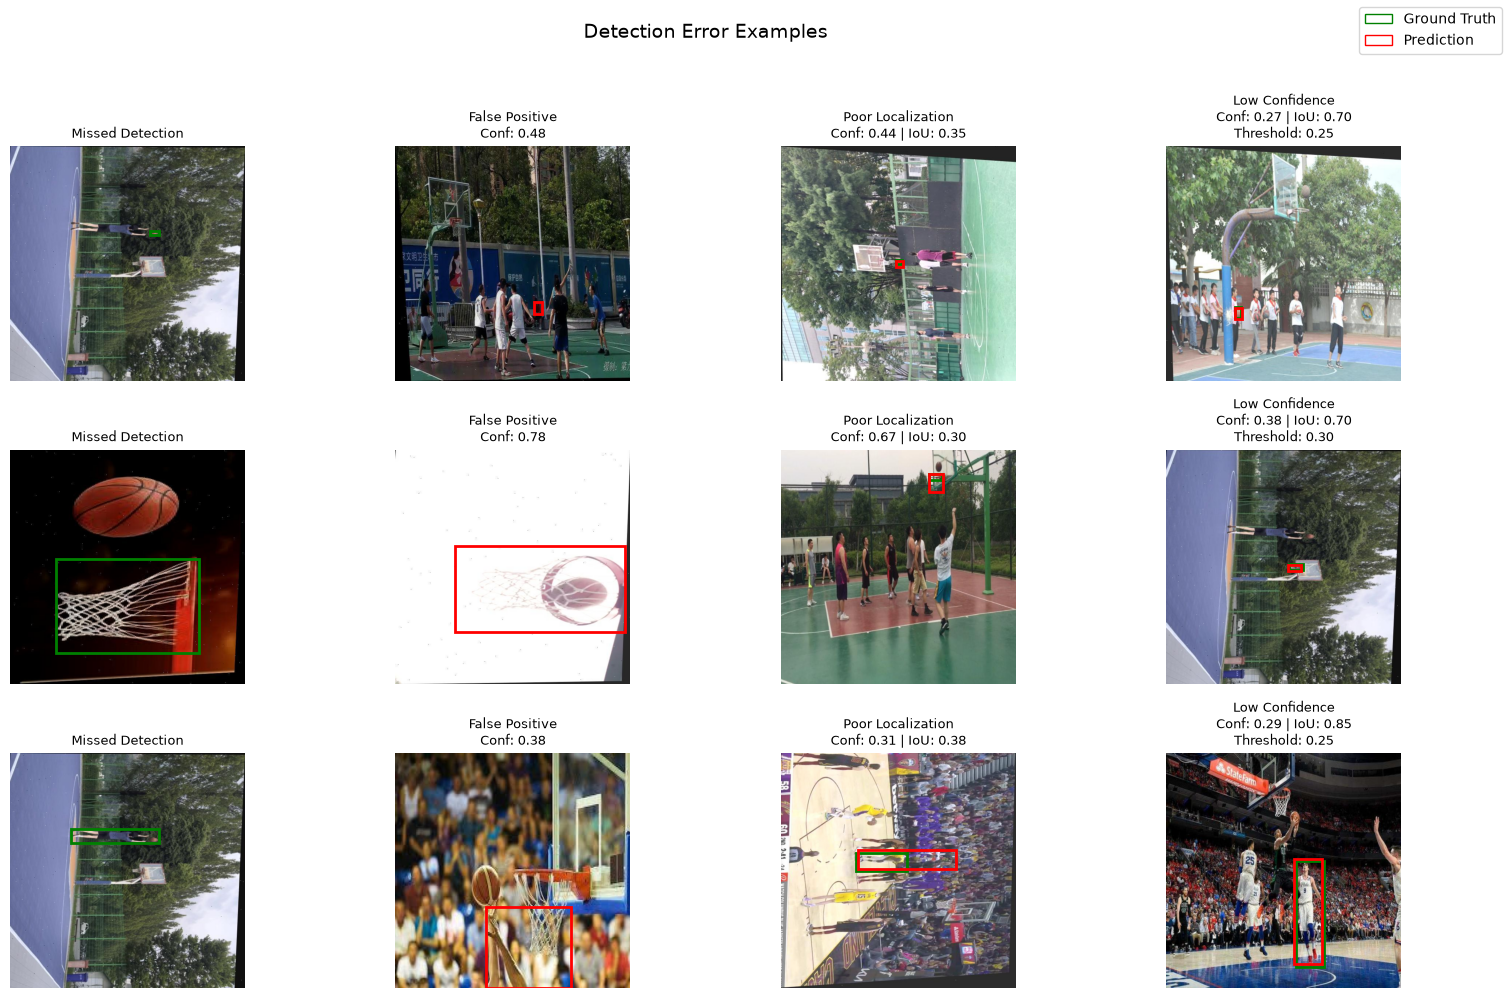

In [54]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches


class_names = list(model.names.values())

error_types = [
    "Missed Detection",
    "False Positive",
    "Poor Localization",
    "Low Confidence"
]

fig, axes = plt.subplots(
    len(class_names),
    len(error_types),
    figsize=(16, 10)
)


for row, class_name in enumerate(class_names):
    class_id = next(
        class_id
        for class_id, name in model.names.items()
        if name == class_name
    )

    for col, error_type in enumerate(error_types):
        ax = axes[row, col]
        example = error_examples[class_name][error_type]

        if example is None:
            ax.set_title(f"{error_type}\nNot Found")
            ax.axis("off")
            continue

        image = cv2.imread(str(example["image"]))
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(image)

        # Ground-truth box
        if "gt_box" in example:
            x1, y1, x2, y2 = example["gt_box"]

            gt_rectangle = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="green",
                facecolor="none"
            )

            ax.add_patch(gt_rectangle)

        # Predicted box
        if "pred_box" in example:
            x1, y1, x2, y2 = example["pred_box"]

            pred_rectangle = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(pred_rectangle)

        title = error_type

        if "confidence" in example:
            title += (
                f"\nConf: {example['confidence']:.2f}"
            )

        if "iou" in example:
            title += (
                f" | IoU: {example['iou']:.2f}"
            )

        if error_type == "Low Confidence":
            title += (
                f"\nThreshold: "
                f"{selected_thresholds[class_id]:.2f}"
            )

        ax.set_title(
            title,
            fontsize=9
        )

        if col == 0:
            ax.set_ylabel(
                class_name,
                fontsize=11,
                fontweight="bold"
            )

        ax.axis("off")


# Figure legend
legend_handles = [
    patches.Patch(
        edgecolor="green",
        facecolor="none",
        label="Ground Truth"
    ),
    patches.Patch(
        edgecolor="red",
        facecolor="none",
        label="Prediction"
    )
]

fig.legend(
    handles=legend_handles,
    loc="upper right"
)

plt.suptitle(
    "Detection Error Examples",
    fontsize=14
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

### 6.4 Basketball-Specific Analysis

Perform additional analysis of basketball detection because reliable ball detection is especially important for tracking and shot detection.

This analysis focuses on how basketball detection performance changes with object size.

Basketball instances are divided into three relative size groups based on the ground-truth bounding-box area in the validation set:

- **Small**
- **Medium**
- **Large**

The selected basketball confidence threshold from Section 6.3.1 is used, while the IoU matching threshold remains fixed at 0.50.

This helps determine whether missed basketball detections are concentrated mainly on small or distant-looking objects.

In [55]:
basketball_class_id = next(
    class_id
    for class_id, class_name in model.names.items()
    if class_name == "basketball"
)

basketball_threshold = selected_thresholds[
    basketball_class_id
]

basketball_records = []


prediction_stream = model.predict(
    source=str(validation_images),
    imgsz=640,
    conf=0.01,
    device=0,
    stream=True,
    verbose=False
)


for result in prediction_stream:
    image_path = Path(result.path)
    label_path = validation_labels / f"{image_path.stem}.txt"

    image_height, image_width = result.orig_shape

    gt_boxes = []

    if label_path.exists():
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines():

            values = list(map(float, line.split()))
            class_id = int(values[0])

            if class_id == basketball_class_id:
                gt_boxes.append(
                    yolo_to_xyxy(
                        values,
                        image_width,
                        image_height
                    )
                )

    predicted_boxes = []

    for box in result.boxes:
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())

        if (
            class_id == basketball_class_id
            and confidence >= basketball_threshold
        ):
            predicted_boxes.append({
                "confidence": confidence,
                "box": box.xyxy[0].cpu().numpy()
            })

    predicted_boxes = sorted(
        predicted_boxes,
        key=lambda item: item["confidence"],
        reverse=True
    )

    matched_gt = set()

    for prediction in predicted_boxes:
        best_iou = 0
        best_gt_index = None

        for gt_index, gt_box in enumerate(gt_boxes):
            if gt_index in matched_gt:
                continue

            iou = calculate_iou(
                prediction["box"],
                gt_box
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_index = gt_index

        if (
            best_gt_index is not None
            and best_iou >= IOU_THRESHOLD
        ):
            matched_gt.add(best_gt_index)

    for gt_index, gt_box in enumerate(gt_boxes):
        box_width = gt_box[2] - gt_box[0]
        box_height = gt_box[3] - gt_box[1]

        relative_area = (
            box_width * box_height
        ) / (
            image_width * image_height
        )

        basketball_records.append({
            "relative_area": relative_area,
            "detected": gt_index in matched_gt
        })


basketball_size_data = pd.DataFrame(
    basketball_records
)

small_limit = basketball_size_data[
    "relative_area"
].quantile(1 / 3)

large_limit = basketball_size_data[
    "relative_area"
].quantile(2 / 3)


def classify_size(relative_area):
    if relative_area <= small_limit:
        return "Small"

    if relative_area <= large_limit:
        return "Medium"

    return "Large"


basketball_size_data["Size"] = basketball_size_data[
    "relative_area"
].apply(classify_size)


basketball_size_summary = (
    basketball_size_data
    .groupby("Size")
    .agg(
        Ground_Truth=("detected", "size"),
        Detected=("detected", "sum")
    )
    .reindex(["Small", "Medium", "Large"])
)

basketball_size_summary["Missed"] = (
    basketball_size_summary["Ground_Truth"]
    - basketball_size_summary["Detected"]
)

basketball_size_summary["Recall"] = (
    basketball_size_summary["Detected"]
    / basketball_size_summary["Ground_Truth"]
)

display(
    basketball_size_summary.round(4)
)

,Ground_Truth,Detected,Missed,Recall
Size,,,,
Small,2401,1387,1014,0.5777
Medium,2350,1514,836,0.6443
Large,2374,2184,190,0.9200


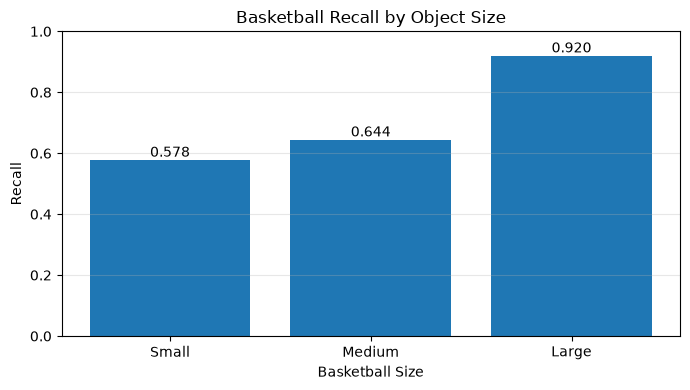

In [56]:
plt.figure(figsize=(7, 4))

bars = plt.bar(
    basketball_size_summary.index,
    basketball_size_summary["Recall"]
)

plt.xlabel("Basketball Size")
plt.ylabel("Recall")
plt.title("Basketball Recall by Object Size")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

for bar, recall in zip(
    bars,
    basketball_size_summary["Recall"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{recall:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Size Analysis Interpretation

Basketball Recall currently increases with object size.

- **Small basketballs** have the lowest Recall and are missed more frequently.
- **Medium basketballs** show better detection performance.
- **Large basketballs** achieve the highest Recall.

These results represent an early baseline after only a few training epochs. The same analysis will be repeated as training progresses to determine whether detection of smaller basketballs improves.